
#Customer Lifetime Value (CLV) Prediction System
---


In [1]:

import pandas as pd
df = pd.read_csv("file.csv")

# Preprocess column names and data
df.rename(columns={
    'CustomerID': 'customer_id',
    'Transaction_Date': 'transaction_date',
    'Gender': 'gender'
}, inplace=True)

df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['amount_spent'] = df[['Online_Spend', 'Offline_Spend']].sum(axis=1)

# Mock columns that were expected in original notebook
df['signup_date'] = df['transaction_date'] - pd.to_timedelta(df['Tenure_Months'].fillna(0) * 30, unit='D')
df['industry'] = 'Retail'
df['channel'] = 'Online'
df['lifecycle_stage'] = 'Active'
df['age'] = 35  # placeholder average age

df.head()


,Unnamed: 0,customer_id,gender,Location,Tenure_Months,Transaction_ID,transaction_date,Product_SKU,Product_Description,Product_Category,...,Online_Spend,Month,Coupon_Code,Discount_pct,amount_spent,signup_date,industry,channel,lifecycle_stage,age
0,0,17850.0,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,2424.5,1,ELEC10,10.0,6924.5,2018-01-06,Retail,Online,Active,35
1,1,17850.0,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,2424.5,1,ELEC10,10.0,6924.5,2018-01-06,Retail,Online,Active,35
2,2,17850.0,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,2424.5,1,ELEC10,10.0,6924.5,2018-01-06,Retail,Online,Active,35
3,3,17850.0,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,2424.5,1,ELEC10,10.0,6924.5,2018-01-06,Retail,Online,Active,35
4,4,17850.0,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,2424.5,1,ELEC10,10.0,6924.5,2018-01-06,Retail,Online,Active,35


Load & Preview Dataset

In [2]:

df = pd.read_csv("clv_dataset.csv", parse_dates=["transaction_date", "signup_date"])
df.head()


,customer_id,transaction_date,amount_spent,signup_date,industry,channel,age,gender,lifecycle_stage
0,1,2021-04-23,381.89,2020-09-27,Travel,Store,21,Female,Legacy
1,1,2021-08-15,81.14,2020-09-27,Travel,Store,21,Female,Legacy
2,1,2021-09-25,299.39,2020-09-27,Travel,Store,21,Female,Legacy
3,1,2020-12-21,17.42,2020-09-27,Travel,Store,21,Female,Legacy
4,2,2020-09-14,47.89,2020-07-19,Travel,Store,53,Male,Legacy


#Exploratory Data Analysis (EDA) & Hypotheses

### Hypotheses:
1. Customers with recent purchases will have higher CLV.
2. Average Order Value (AOV) will differ across industries.
3. Customers using mobile may have higher churn.
4. Lifecycle stage influences revenue potential.

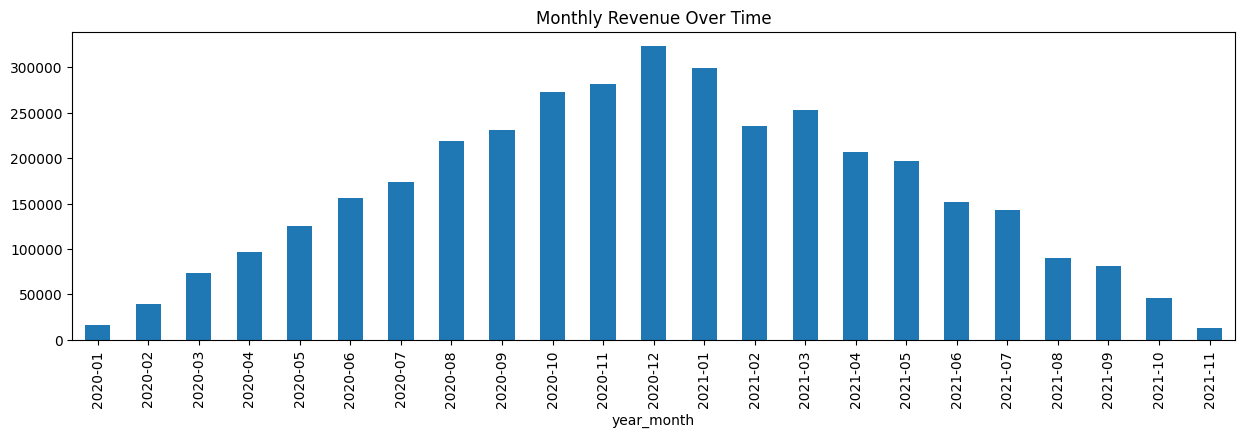

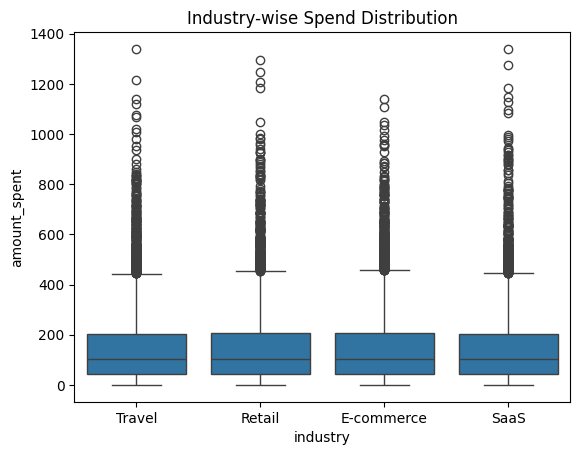

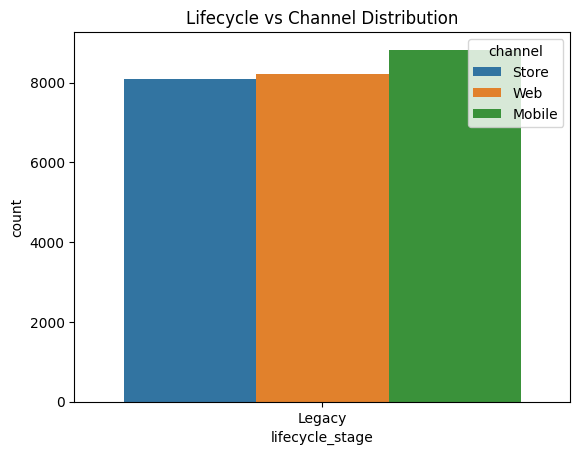

In [4]:

import matplotlib.pyplot as plt
import seaborn as sns

df['year_month'] = df['transaction_date'].dt.to_period('M')
monthly_rev = df.groupby('year_month')['amount_spent'].sum()
monthly_rev.plot(kind='bar', figsize=(15, 4), title="Monthly Revenue Over Time")
plt.show()

sns.boxplot(x='industry', y='amount_spent', data=df)
plt.title("Industry-wise Spend Distribution")
plt.show()

sns.countplot(data=df, x='lifecycle_stage', hue='channel')
plt.title("Lifecycle vs Channel Distribution")
plt.show()



## Feature Engineering
- **Recency**: Days since last purchase
- **Frequency**: Number of transactions
- **Monetary**: Total value spent
- **Tenure**: Days since signup
- **AOV**: Average order value
- **Age Group** and **Lifecycle Stage Encoding**


In [ ]:

ref_date = df['transaction_date'].max()

rfm = df.groupby('customer_id').agg({
    'transaction_date': [lambda x: (ref_date - x.max()).days, 'count'],
    'amount_spent': ['sum', 'mean'],
    'signup_date': lambda x: (ref_date - x.iloc[0]).days,
    'age': 'mean'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary', 'aov', 'tenure', 'age']
rfm = rfm.merge(df[['customer_id', 'industry', 'channel', 'gender', 'lifecycle_stage']].drop_duplicates(), on='customer_id', how='left')

# Feature encoding
rfm['gender'] = rfm['gender'].map({'Male': 0, 'Female': 1})
rfm = pd.get_dummies(rfm, columns=['industry', 'channel', 'lifecycle_stage'], drop_first=True)

# Age group
rfm['age_group'] = pd.cut(rfm['age'], bins=[17, 25, 35, 50, 65], labels=['18-25', '26-35', '36-50', '51-65'])
rfm = pd.get_dummies(rfm, columns=['age_group'], drop_first=True)

rfm.head()


,customer_id,recency,frequency,monetary,aov,tenure,age,gender,industry_Retail,industry_SaaS,industry_Travel,channel_Store,channel_Web,age_group_26-35,age_group_36-50,age_group_51-65
0,1,61,4,779.84,194.960000,424,21.0,1,False,False,True,True,False,False,False,False
1,2,239,3,296.03,98.676667,494,53.0,0,False,False,True,True,False,False,False,True
2,3,316,5,794.12,158.824000,592,27.0,0,True,False,False,False,True,True,False,False
3,4,231,3,91.48,30.493333,396,45.0,0,False,False,False,False,False,False,True,False
4,5,277,7,583.28,83.325714,641,23.0,0,False,False,False,False,True,False,False,False



##Probabilistic CLV Estimation using BG/NBD + Gamma-Gamma
- Expected number of future transactions per customer
- Expected average value per transaction
- Then calculate basic predicted CLV

In [ ]:

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# Step 1: Prepare summary data
summary = summary_data_from_transaction_data(df, 'customer_id', 'transaction_date', monetary_value_col='amount_spent', observation_period_end=df['transaction_date'].max())
summary = summary[summary['monetary_value'] > 0]

# Step 2: Fit BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Predict transactions for 6 months
summary['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(180, summary['frequency'], summary['recency'], summary['T'])

# Step 3: Fit Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(summary['frequency'], summary['monetary_value'])

summary['predicted_avg_value'] = ggf.conditional_expected_average_profit(summary['frequency'], summary['monetary_value'])

# Calculate basic CLV prediction: transactions * value
summary['probabilistic_clv'] = summary['predicted_purchases'] * summary['predicted_avg_value']

summary.head()


,frequency,recency,T,monetary_value,predicted_purchases,predicted_avg_value,probabilistic_clv
customer_id,,,,,,,
1,3.0,278.0,339.0,254.140000,1.305413,255.464501,333.486640
2,2.0,198.0,437.0,124.070000,0.310043,127.705221,39.594082
3,4.0,223.0,539.0,140.010000,0.120500,141.737084,17.079386
4,2.0,154.0,385.0,10.665000,0.299859,15.744839,4.721228
5,6.0,312.0,589.0,80.223333,0.194855,81.633228,15.906639


In [ ]:

# Merge probabilistic CLV into the RFM dataset
rfm = rfm.merge(summary[['predicted_purchases', 'predicted_avg_value', 'probabilistic_clv']], left_on='customer_id', right_index=True, how='left')
rfm.fillna(0, inplace=True)
rfm.head()


,customer_id,recency,frequency,monetary,aov,tenure,age,gender,industry_Retail,industry_SaaS,industry_Travel,channel_Store,channel_Web,age_group_26-35,age_group_36-50,age_group_51-65,predicted_purchases,predicted_avg_value,probabilistic_clv
0,1,61,4,779.84,194.960000,424,21.0,1,False,False,True,True,False,False,False,False,1.305413,255.464501,333.486640
1,2,239,3,296.03,98.676667,494,53.0,0,False,False,True,True,False,False,False,True,0.310043,127.705221,39.594082
2,3,316,5,794.12,158.824000,592,27.0,0,True,False,False,False,True,True,False,False,0.120500,141.737084,17.079386
3,4,231,3,91.48,30.493333,396,45.0,0,False,False,False,False,False,False,True,False,0.299859,15.744839,4.721228
4,5,277,7,583.28,83.325714,641,23.0,0,False,False,False,False,True,False,False,False,0.194855,81.633228,15.906639



## XGBoost Modeling + SHAP + CLV Segmentation
- Train XGBoost using RFM + probabilistic CLV features
- Tune hyperparameters (GridSearch)
- Use SHAP to find most important features
- Remove low-impact features
- Predict refined CLV
- Segment customers into High, Medium, Low tiers


In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Target: probabilistic CLV
X = rfm.drop(columns=['customer_id', 'probabilistic_clv'])
y = rfm['probabilistic_clv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Basic XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid Search for hyperparameter tuning
param_grid = {
    'max_depth': [3, 4, 5],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
}
grid = GridSearchCV(xgb_model, param_grid, cv=3, scoring='neg_mean_absolute_error', verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
MAE: 2.87, RMSE: 10.18


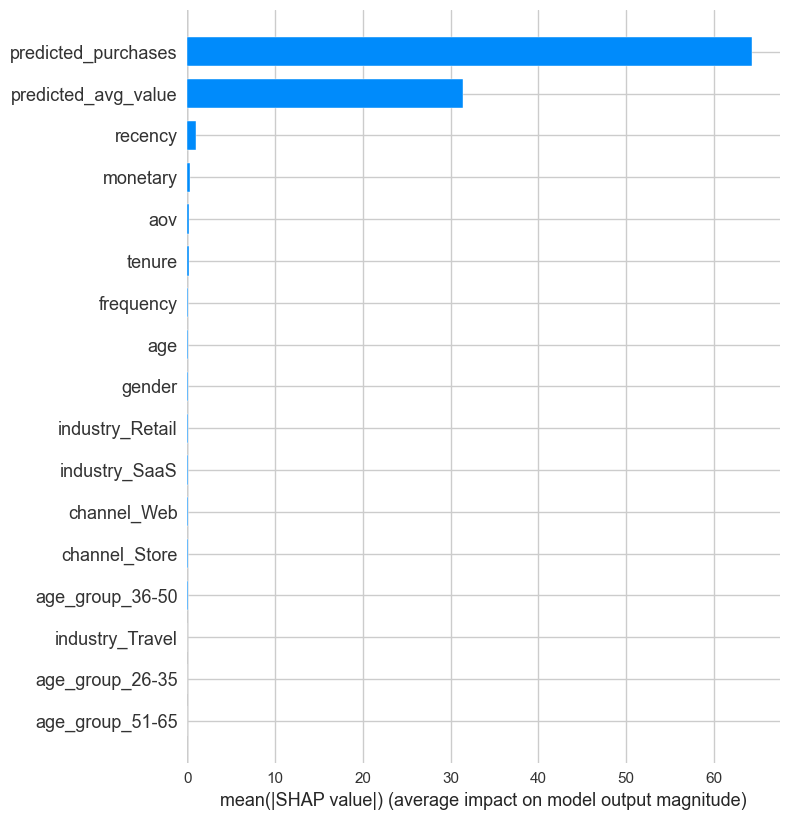

In [ ]:

import shap

explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

# Plot summary
shap.summary_plot(shap_values, X_train, plot_type="bar")


In [ ]:


# Final predictions on entire dataset
rfm['predicted_clv'] = best_model.predict(X)

# Segment customers
quantiles = rfm['predicted_clv'].quantile([0.33, 0.66]).values
def segment_clv(clv):
    if clv <= quantiles[0]:
        return 'Low'
    elif clv <= quantiles[1]:
        return 'Medium'
    else:
        return 'High'

rfm['clv_segment'] = rfm['predicted_clv'].apply(segment_clv)

rfm[['customer_id', 'predicted_clv', 'clv_segment']].head()


,customer_id,predicted_clv,clv_segment
0,1,327.812561,High
1,2,41.118156,Medium
2,3,16.923323,Low
3,4,4.582825,Low
4,5,15.196515,Low


In [ ]:

# Export full data
rfm.to_csv("final_customer_clv_segments.csv", index=False)

# Export VIPs and churn risk segments
vip_customers = rfm[rfm['clv_segment'] == 'High'].sort_values(by='predicted_clv', ascending=False).head(100)
churn_risk = rfm[rfm['predicted_purchases'] < 1]

vip_customers.to_csv("top_100_vips.csv", index=False)
churn_risk.to_csv("churn_risk_customers.csv", index=False)
